In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
df = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "processed" /
    "insurance_analytics.csv"
)

df.head()

,patient_id,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,hospital_visits,medication_count,...,esg_score,pandemic_risk_index,future_health_cost,risk_level,claims_to_premium_ratio,member_segment,ibnr_reserve,forecast_claims,risk_adjustment_score,recommended_premium
0,1,69,Female,25.3,0,0,1,1,1,3,...,84.55,0.511,27769.38,High,2.001611,Loss Making,1522.0248,19620.241437,7.839,10250.09695
1,2,32,Male,31.0,0,0,0,0,1,1,...,66.94,0.801,13585.13,Low,1.987047,Loss Making,705.7992,9118.144319,2.370,4545.22800
2,3,89,Male,39.2,0,0,1,0,1,3,...,61.35,0.410,17540.43,Medium,1.424980,Loss Making,901.1576,11884.502847,5.656,8352.10680
3,4,78,Female,25.2,0,1,0,1,4,5,...,67.46,0.275,40978.02,High,2.828050,Loss Making,2445.6976,32651.677182,10.716,11968.39960
4,5,38,Female,36.3,0,0,0,0,2,1,...,35.44,0.942,14812.69,Medium,1.979055,Loss Making,745.7080,9759.247285,3.249,4863.02790


In [3]:
df["default"] = (

    (
        df["claims_to_premium_ratio"] > 1.20

    )

    |

    (
        df["hospital_debt_ratio"] > 0.70

    )

    |

    (
        df["pandemic_risk_index"] > 0.80

    )

).astype(int)

df["default"].value_counts()

default
1    9242
0     758
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split

features = [

    "age",

    "bmi",

    "hospital_visits",

    "medication_count",

    "annual_claim_amount",

    "premium_paid",

    "claims_to_premium_ratio",

    "hospital_debt_ratio",

    "esg_score",

    "pandemic_risk_index",

    "risk_adjustment_score",

]

X = df[features]

y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(8000, 11)
(2000, 11)


In [5]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(max_iter=1000)

logistic.fit(

    X_train,

    y_train

)

c:\Users\Mirza Shareef Baig\OneDrive\Desktop\Healthrisk-ai\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [6]:
from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    roc_auc_score,

)

predictions = logistic.predict(X_test)

probabilities = logistic.predict_proba(X_test)[:,1]

print(classification_report(

    y_test,

    predictions

))

print(

    "ROC AUC:",

    roc_auc_score(

        y_test,

        probabilities

    )

)

              precision    recall  f1-score   support

           0       0.74      0.68      0.71       152
           1       0.97      0.98      0.98      1848

    accuracy                           0.96      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.96      0.96      0.96      2000

ROC AUC: 0.9824241000227841


In [7]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [8]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

gb_predictions = gb_model.predict(X_test)

gb_probabilities = gb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, gb_predictions))

print(
    "Gradient Boosting ROC AUC:",
    roc_auc_score(y_test, gb_probabilities)
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       152
           1       1.00      1.00      1.00      1848

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Gradient Boosting ROC AUC: 0.9997294372294372


In [9]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, probabilities),
        roc_auc_score(y_test, gb_probabilities)
    ]
})

comparison

,Model,ROC_AUC
0,Logistic Regression,0.982424
1,Gradient Boosting,0.999729


In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,claims_to_premium_ratio,6.192895e-01
7,hospital_debt_ratio,2.112190e-01
9,pandemic_risk_index,1.694915e-01
10,risk_adjustment_score,5.255350e-15
4,annual_claim_amount,3.682124e-15
5,premium_paid,3.280088e-15
1,bmi,3.260804e-15
8,esg_score,2.268483e-15
0,age,4.093516e-16
3,medication_count,1.821296e-17


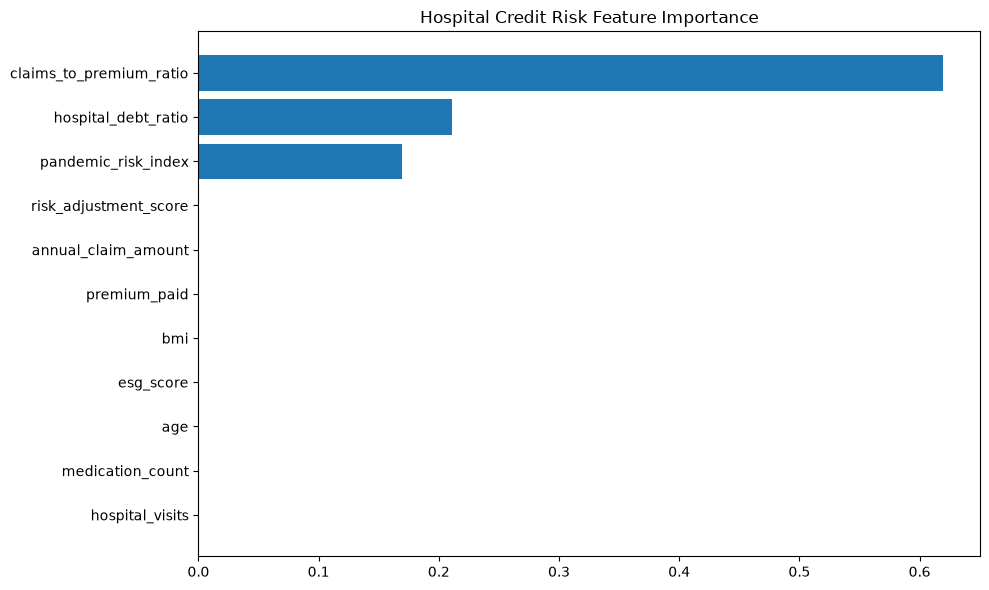

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Hospital Credit Risk Feature Importance")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT /
    "reports" /
    "hospital_credit_feature_importance.png",
    dpi=300
)

plt.show()

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from financial.pharma import PharmaceuticalAnalytics

pharma = PharmaceuticalAnalytics()

pipeline = pharma.portfolio_optimization()
summary = pharma.portfolio_summary()

summary

{'companies_analyzed': 5,
 'drugs_analyzed': 5,
 'avg_success_probability': np.float64(0.6135),
 'total_rnpv': np.float64(903.81),
 'avg_rnpv': np.float64(180.76),
 'total_revenue_at_risk': np.float64(1927.5),
 'recommendation_distribution': {'Invest': 4, 'Monitor': 1, 'Avoid': 0}}

In [14]:
pipeline[
    [
        "company",
        "drug",
        "phase",
        "success_probability",
        "patent_cliff_risk",
        "revenue_at_risk",
        "rnpv",
        "portfolio_score",
        "investment_recommendation",
    ]
]

,company,drug,phase,success_probability,patent_cliff_risk,revenue_at_risk,rnpv,portfolio_score,investment_recommendation
0,AstraNova,AN-101,Phase III,0.7150,Moderate Patent Cliff Risk,420.0,359.090909,432.045455,Invest
3,OncoLife,OL-440,Phase III,0.6925,High Patent Cliff Risk,975.0,360.428249,340.464125,Invest
1,BioCure,BC-220,Phase II,0.5575,Low Patent Cliff Risk,127.5,103.663001,306.331501,Invest
2,MediGen,MG-330,Phase I,0.5700,Low Patent Cliff Risk,90.0,43.050084,303.525042,Invest
4,NeuroPath,NP-550,Phase II,0.5325,Moderate Patent Cliff Risk,315.0,37.576544,217.038272,Monitor


In [15]:
processed_path = PROJECT_ROOT / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)

pipeline.to_csv(
    processed_path / "pharma_analytics.csv",
    index=False
)

In [16]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from simulation.scenario_engine import HealthRiskSimulationEngine

engine = HealthRiskSimulationEngine(starting_capital=1_000_000)

history = engine.run_simulation(years=10)

score = engine.final_score()

history.head(), score

(   quarter                  scenario       category  \
 0        1           Inflation Shock          Macro   
 1        2               Drug Recall         Pharma   
 2        3      Pandemic Declaration  Public Health   
 3        4      Pandemic Declaration  Public Health   
 4        5  New Breakthrough Therapy     Innovation   
 
                                          description  insurance_value  \
 0  Medical cost inflation increases claims and pr...        264000.00   
 1  Major drug recall hurts pharma equity and incr...        258720.00   
 2  Claims surge, hospital stress, vaccine compani...        212150.40   
 3  Claims surge, hospital stress, vaccine compani...        173963.33   
 4  Successful therapy improves outcomes and boost...        180921.86   
 
    hospital_bonds_value  pharma_equity_value  credit_facilities_value  \
 0             230000.00            291000.00                142500.00   
 1             223100.00            232800.00                136800.

In [17]:
processed_path = PROJECT_ROOT / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)

history.to_csv(
    processed_path / "simulation_history.csv",
    index=False
)

engine.scenario_catalog().to_csv(
    processed_path / "scenario_catalog.csv",
    index=False
)

score

{'total_score': 620,
 'final_portfolio_value': np.float64(815076.56),
 'certification_tier': 'HealthRisk Analyst Bronze',
 'quarters_completed': 40}

In [1]:
from explainability.partial_dependence import generate_pdp_report

features = [
    "age",
    "bmi",
    "hospital_visits",
    "annual_claim_amount"
]

paths = generate_pdp_report(
    model=ensemble_model,
    X=X_test,
    features=features,
    output_dir=PROJECT_ROOT / "reports"
)

paths

ModuleNotFoundError: No module named 'explainability'